# NASDAQ-100 RecSys — 1.2-A Modeling

**Goal:** Build four progressively sophisticated recommendation models that rank NASDAQ-100 stocks by predicted 5-day forward return.  
Each model is a complete, self-contained implementation — no black-box wrappers.

---

## RecSys Framing

| RecSys concept | Financial meaning |
|---|---|
| **User** | A portfolio strategy / investor risk profile |
| **Item** | A NASDAQ-100 stock (ticker) |
| **Rating** | 5-day forward log return (continuous) or rank |
| **Recommendation** | Top-N stocks ranked by predicted forward return |
| **Implicit feedback** | Historical price behaviour (no explicit ratings exist) |

---

## Model Roadmap

| # | Model | Type | Key idea |
|---|---|---|---|
| 0 | **Momentum baseline** | Heuristic | Recommend yesterday's winners |
| 1 | **Collaborative filter** | Matrix factorisation (SVD) | Tickers with similar past return patterns score alike |
| 2 | **Content-based filter** | Cosine similarity + regression | Tickers with similar feature profiles score alike |
| 3 | **Hybrid** | LightGBM ranker | Combines all signals; learns optimal weights |

---

**Sections:**
1. Setup & load artefacts  
2. Model 0 — Momentum baseline  
3. Model 1 — Collaborative filtering (SVD)  
4. Model 2 — Content-based filtering  
5. Model 3 — Hybrid LightGBM ranker  
6. Unified prediction interface  
7. Save all models

---
## 1. Setup & Load Artefacts

In [86]:
import os, warnings, joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import wandb

from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import spearmanr

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12, 'axes.labelsize': 10})

SEED        = 42
ARTEFACT    = './artefacts'
MODEL_PATH  = './models'
os.makedirs(MODEL_PATH, exist_ok=True)

np.random.seed(SEED)

wandb.init(
    project = "nasdaq100-recsys",
    name    = "modeling-1.2-A",
    config  = {
        # SVD
        "svd_n_components"       : 30,
        # Content-based
        "cb_n_neighbors"         : 10,
        "cb_alpha_blend"         : 0.6,
        "cb_ridge_alpha"         : 10.0,
        # LightGBM
        "lgbm_learning_rate"     : 0.05,
        "lgbm_num_leaves"        : 63,
        "lgbm_min_child_samples" : 50,
        "lgbm_feature_fraction"  : 0.8,
        "lgbm_bagging_fraction"  : 0.8,
        "lgbm_lambda_l2"         : 1.0,
        "lgbm_num_boost_round"   : 500,
        "lgbm_early_stopping"    : 30,
        "seed"                   : SEED,
    }
)

wandb: setting up run gtso67xs
wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /Users/goodmac/Study/STU/ISA/project/ISA/wandb/run-20260323_163324-gtso67xs
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run modeling-1.2-A
wandb: ⭐️ View project at https://wandb.ai/xkoliasnikov-fiit-stu/nasdaq100-recsys
wandb: 🚀 View run at https://wandb.ai/xkoliasnikov-fiit-stu/nasdaq100-recsys/runs/gtso67xs


In [87]:
# ── Load data artefacts from 1.1-B ───────────────────────────────────────────
df_train = pd.read_parquet(f'{ARTEFACT}/df_train.parquet')
df_val   = pd.read_parquet(f'{ARTEFACT}/df_val.parquet')
df_test  = pd.read_parquet(f'{ARTEFACT}/df_test.parquet')

X_train = np.load(f'{ARTEFACT}/X_train.npy')
X_val   = np.load(f'{ARTEFACT}/X_val.npy')
X_test  = np.load(f'{ARTEFACT}/X_test.npy')

y_train_reg = np.load(f'{ARTEFACT}/y_train_reg.npy')
y_val_reg   = np.load(f'{ARTEFACT}/y_val_reg.npy')
y_test_reg  = np.load(f'{ARTEFACT}/y_test_reg.npy')

y_train_cls = np.load(f'{ARTEFACT}/y_train_cls.npy')
y_val_cls   = np.load(f'{ARTEFACT}/y_val_cls.npy')
y_test_cls  = np.load(f'{ARTEFACT}/y_test_cls.npy')

item_sim_corr   = pd.read_parquet(f'{ARTEFACT}/item_sim_corr.parquet')
item_sim_cosine = pd.read_parquet(f'{ARTEFACT}/item_sim_cosine.parquet')

scaler       = joblib.load(f'{ARTEFACT}/robust_scaler.pkl')
FEATURE_COLS = joblib.load(f'{ARTEFACT}/feature_cols.pkl')

TICKERS = df_train['Ticker'].unique().tolist()
N_TICKERS = len(TICKERS)

print(f'Train : {df_train.shape}  |  Val : {df_val.shape}  |  Test : {df_test.shape}')
print(f'Tickers: {N_TICKERS}  |  Features: {len(FEATURE_COLS)}')

Train : (313288, 54)  |  Val : (85894, 54)  |  Test : (93472, 54)
Tickers: 85  |  Features: 49


In [88]:
# ── Shared evaluation helpers ─────────────────────────────────────────────────
# All models are evaluated on the same three metrics:
#   RMSE       — regression accuracy of the predicted return
#   IC         — Information Coefficient (Spearman rank correlation between
#                predicted and actual returns, averaged across days)
#   Hit Rate   — fraction of top-N recommended stocks that have positive returns

def ic_score(df, pred_col, target_col='Target_Ret_5d'):
    """Mean daily Spearman IC across all dates."""
    daily_ic = (
        df.assign(pred=pred_col)
          .groupby('Date')
          .apply(lambda g: spearmanr(g['pred'], g[target_col])[0])
    )
    return daily_ic.mean(), daily_ic.std()

def hit_rate(df, pred_col, top_n=10, target_col='Target_Ret_5d'):
    """Fraction of top-N recommendations with positive 5-day return."""
    def _daily(g):
        top = g.nlargest(top_n, 'pred')
        return (top[target_col] > 0).mean()
    return df.assign(pred=pred_col).groupby('Date').apply(_daily).mean()

def evaluate(name, df, predictions, top_n=10, split='val'):
    rmse = np.sqrt(mean_squared_error(df['Target_Ret_5d'], predictions))
    mae  = mean_absolute_error(df['Target_Ret_5d'], predictions)
    ic, ic_std = ic_score(df, predictions)
    hr = hit_rate(df, predictions, top_n=top_n)
    print(f'  {name:<30}  RMSE={rmse:.5f}  MAE={mae:.5f}  IC={ic:.4f}±{ic_std:.4f}  HR@{top_n}={hr:.3f}')

    # summary for the run overview table
    prefix = f"{name}/{split}"
    wandb.summary[f"{prefix}/rmse"]     = rmse
    wandb.summary[f"{prefix}/mae"]      = mae
    wandb.summary[f"{prefix}/ic"]       = ic
    wandb.summary[f"{prefix}/ic_std"]   = ic_std
    wandb.summary[f"{prefix}/hit_rate"] = hr

    return dict(model=name, rmse=rmse, mae=mae, ic=ic, ic_std=ic_std, hit_rate=hr)

RESULTS = []   # accumulate all model results here

---
## 2. Model 0 — Momentum Baseline

**Idea:** Stocks that performed well over the past N days will continue to perform well (momentum anomaly).  
This is the simplest possible RecSys: sort tickers by their recent return and recommend the top-N.

**Why this is a valid baseline:**  
Momentum is one of the most robust empirical anomalies in finance (Jegadeesh & Titman, 1993).  
Any model that cannot beat this baseline does not add value.

**Prediction score = 21-day momentum** (sum of past 21 daily log returns).

In [89]:
class MomentumBaseline:
    """
    Scores each stock by its recent momentum.
    No fitting required — purely rule-based.
    """
    def __init__(self, momentum_col='Momentum_21d'):
        self.momentum_col = momentum_col

    def predict(self, df):
        """Return a Series of scores aligned with df index."""
        return df[self.momentum_col].values

    def recommend(self, df, date, top_n=10):
        """Return top-N tickers for a given date."""
        day = df[df['Date'] == date].copy()
        day['score'] = self.predict(day)
        return day.nlargest(top_n, 'score')[['Ticker', 'score']].reset_index(drop=True)


momentum_model = MomentumBaseline(momentum_col='Momentum_21d')

print('=== Model 0: Momentum Baseline ===')
print('Validation:')
res = evaluate('Momentum baseline', df_val, momentum_model.predict(df_val), split='val')
RESULTS.append({**res, 'split': 'val'})

print('Test:')
res = evaluate('Momentum baseline', df_test, momentum_model.predict(df_test), split='test')
RESULTS.append({**res, 'split': 'test'})

=== Model 0: Momentum Baseline ===
Validation:
  Momentum baseline               RMSE=0.11178  MAE=0.08180  IC=-0.0246±0.2216  HR@10=0.537
Test:
  Momentum baseline               RMSE=0.11729  MAE=0.08578  IC=0.0041±0.2249  HR@10=0.535


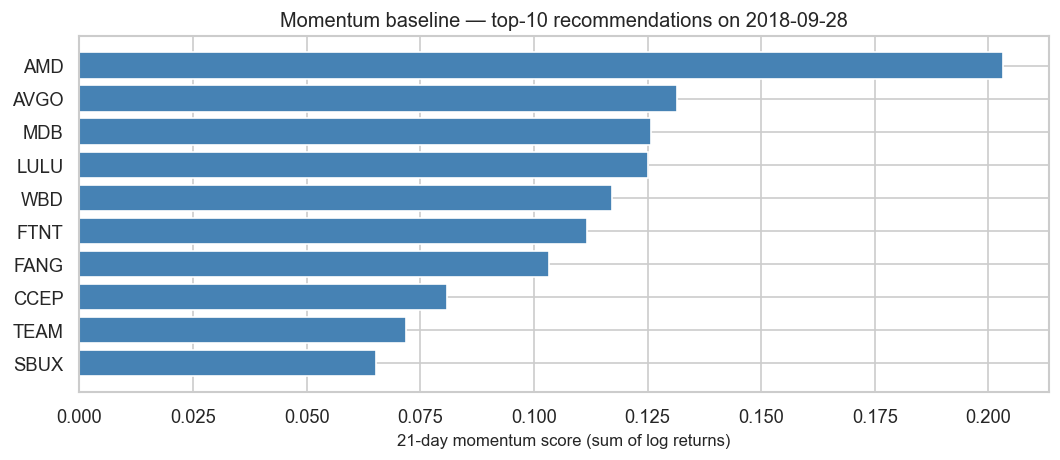

In [90]:
# ── Visualise momentum baseline recommendations on a sample date ───────────────
sample_date = df_val['Date'].unique()[60]  # pick a date in the middle of val set
top10 = momentum_model.recommend(df_val, sample_date, top_n=10)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(top10['Ticker'][::-1], top10['score'][::-1], color='steelblue')
ax.set_xlabel('21-day momentum score (sum of log returns)')
ax.set_title(f'Momentum baseline — top-10 recommendations on {sample_date.date()}')
plt.tight_layout()
plt.show()

---
## 3. Model 1 — Collaborative Filtering (SVD)

**Idea:** Build a Date × Ticker matrix of historical returns.  
Decompose it with Truncated SVD to learn **latent factor representations** of dates (contexts) and tickers (items).  
Reconstruct the matrix — the reconstructed values are smoothed return predictions.

**Why SVD for RecSys?**  
Classic collaborative filtering assumes similar users give similar ratings.  
Here, similar *market regimes* (dates) produce similar cross-sectional return patterns.  
SVD finds the low-rank structure — the few latent factors (e.g. 'tech momentum', 'value vs growth') that drive most of the cross-sectional return dispersion.

**Pipeline:**
1. Pivot: Date × Ticker → log return matrix (fill missing with 0)
2. Fit TruncatedSVD on train
3. Transform val/test dates
4. Reconstruct → predicted returns

In [91]:
class SVDCollaborativeFilter:
    """
    Matrix-factorisation collaborative filter.
    Decomposes the Date × Ticker return matrix into latent factors.
    """
    def __init__(self, n_components=30, random_state=42):
        self.n_components   = n_components
        self.svd            = TruncatedSVD(n_components=n_components,
                                           random_state=random_state)
        self.tickers_       = None
        self.R_mean_        = None   # per-ticker mean return (bias)

    def _build_matrix(self, df):
        return df.pivot_table(index='Date', columns='Ticker',
                              values='Log_Return').fillna(0)

    def fit(self, df_train):
        R = self._build_matrix(df_train)
        self.tickers_ = R.columns.tolist()
        # Subtract per-ticker mean before decomposition (remove bias)
        self.R_mean_  = R.mean(axis=0)
        R_centered    = R - self.R_mean_
        self.svd.fit(R_centered)
        # Reconstruct training matrix for diagnostics
        self._explained_var = self.svd.explained_variance_ratio_.sum()
        print(f'  SVD fitted | components={self.n_components} | '
              f'explained variance={self._explained_var:.3f}')
        return self

    def _reconstruct(self, df):
        R = self._build_matrix(df)
        # Align columns — use only tickers seen during training
        R = R.reindex(columns=self.tickers_, fill_value=0)
        R_centered = R - self.R_mean_
        coords     = self.svd.transform(R_centered)          # Date latent vectors
        R_hat      = coords @ self.svd.components_           # reconstruct
        R_hat_df   = pd.DataFrame(R_hat + self.R_mean_.values,
                                  index=R.index, columns=self.tickers_)
        return R_hat_df

    def predict(self, df):
        """Return predicted return for each (Date, Ticker) row in df."""
        R_hat = self._reconstruct(df)
        # Map back to the original df row order
        R_long = R_hat.stack().reset_index()
        R_long.columns = ['Date', 'Ticker', 'pred']
        merged = df[['Date', 'Ticker']].merge(R_long, on=['Date', 'Ticker'], how='left')
        return merged['pred'].fillna(0).values

    def recommend(self, date, top_n=10):
        """Return top-N tickers for a given date using the reconstructed matrix."""
        if not hasattr(self, '_R_hat_val'):
            raise RuntimeError('Call predict() first to cache the reconstruction.')
        row = self._R_hat_val.loc[date] if date in self._R_hat_val.index else None
        if row is None:
            return pd.DataFrame()
        return row.sort_values(ascending=False).head(top_n).reset_index()\
                  .rename(columns={'Ticker': 'Ticker', 0: 'score'})


# ── Fit & evaluate ────────────────────────────────────────────────────────────
svd_cf = SVDCollaborativeFilter(n_components=30)
svd_cf.fit(df_train)

svd_val_preds  = svd_cf.predict(df_val)
svd_test_preds = svd_cf.predict(df_test)

print('\n=== Model 1: SVD Collaborative Filter ===')
print('Validation:')
res = evaluate('SVD collaborative filter', df_val, svd_val_preds, split='val')
RESULTS.append({**res, 'split': 'val'})
print('Test:')
res = evaluate('SVD collaborative filter', df_test, svd_test_preds, split='test')
RESULTS.append({**res, 'split': 'test'})

  SVD fitted | components=30 | explained variance=0.794

=== Model 1: SVD Collaborative Filter ===
Validation:
  SVD collaborative filter        RMSE=0.05322  MAE=0.03818  IC=-0.0131±0.1997  HR@10=0.549
Test:
  SVD collaborative filter        RMSE=0.05494  MAE=0.03971  IC=-0.0031±0.1814  HR@10=0.530


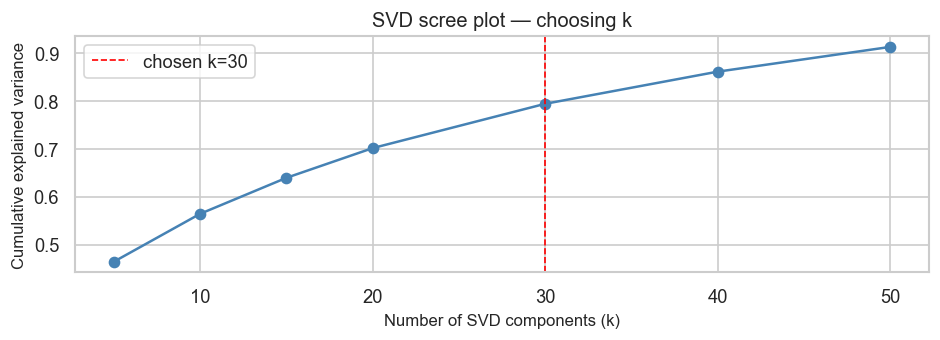


Interpretation:
  - The scree plot shows diminishing returns after k ≈ 20-30.
  - k=30 captures the dominant latent factors (macro regimes, sector rotations)
    without overfitting to noise in high-frequency return variation.
  - Increasing k beyond 30 adds very little explained variance but
    significantly increases the risk of overfitting to training-set noise.



In [92]:
# ── Explained variance vs number of components ────────────────────────────────
ev_ratios = []
for k in [5, 10, 15, 20, 30, 40, 50]:
    R_train = df_train.pivot_table(index='Date', columns='Ticker',
                                   values='Log_Return').fillna(0)
    svd_tmp = TruncatedSVD(n_components=k, random_state=SEED)
    svd_tmp.fit(R_train)
    ev_ratios.append((k, svd_tmp.explained_variance_ratio_.sum()))

ev_df = pd.DataFrame(ev_ratios, columns=['k', 'explained_var'])

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(ev_df['k'], ev_df['explained_var'], marker='o', color='steelblue')
ax.axvline(30, color='red', lw=1, linestyle='--', label='chosen k=30')
ax.set_xlabel('Number of SVD components (k)')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('SVD scree plot — choosing k')
ax.legend()
plt.tight_layout()
plt.show()

print("""
Interpretation:
  - The scree plot shows diminishing returns after k ≈ 20-30.
  - k=30 captures the dominant latent factors (macro regimes, sector rotations)
    without overfitting to noise in high-frequency return variation.
  - Increasing k beyond 30 adds very little explained variance but
    significantly increases the risk of overfitting to training-set noise.
""")

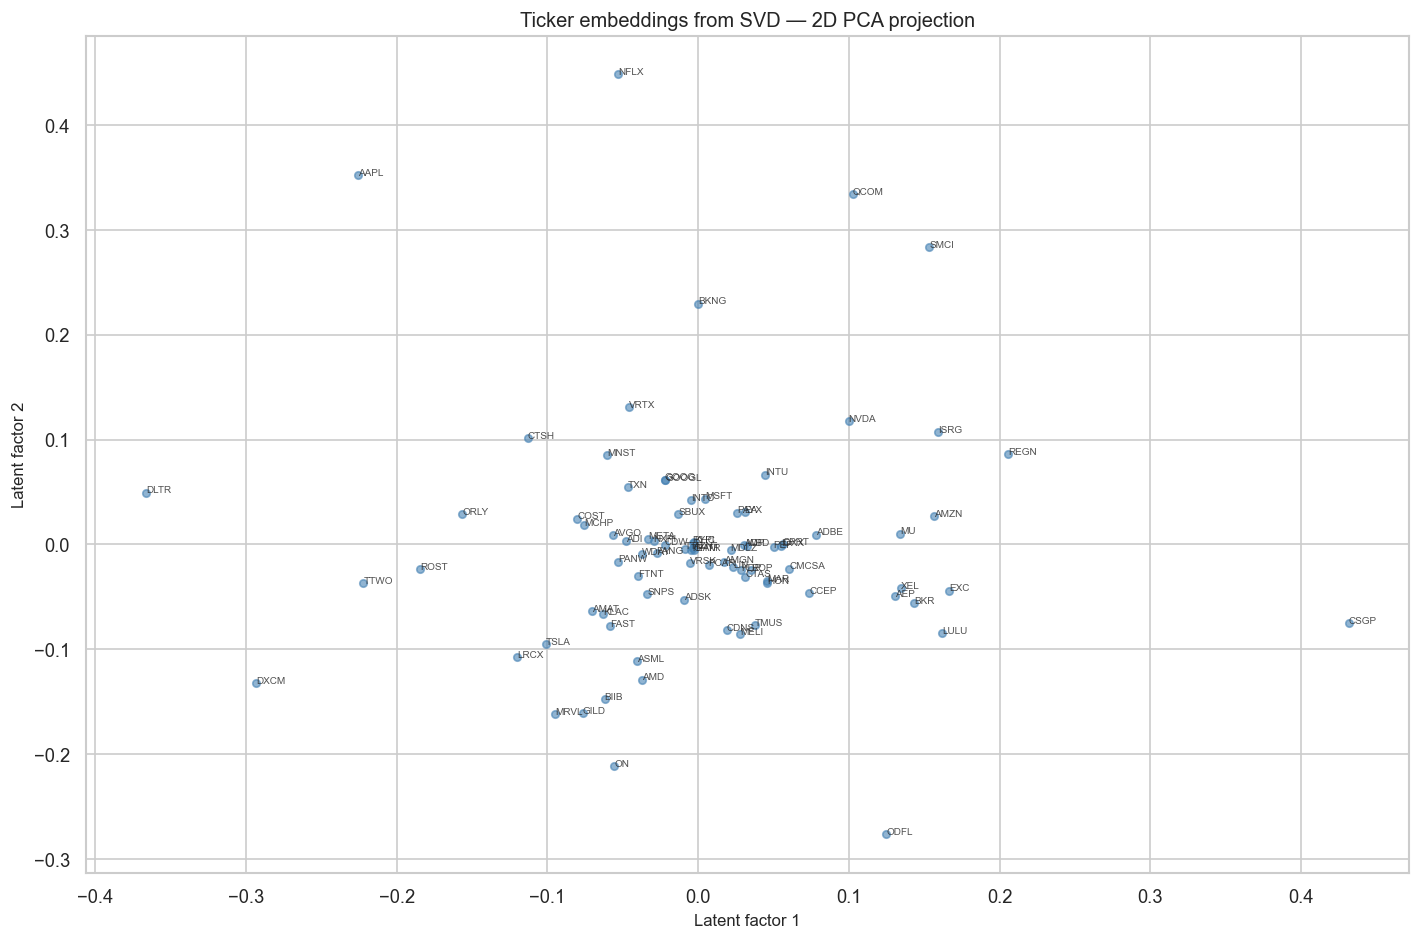


Interpretation:
  - Tickers clustered together in this 2D space have similar latent return patterns.
  - Visible clusters typically correspond to sectors:
    semiconductors, megacap software, biotech, consumer names.
  - Tickers far from all clusters are idiosyncratic movers — less predictable
    from the collaborative filter alone, making them good candidates for the
    content-based model.



In [93]:
# ── Visualise ticker latent factors (2D PCA of SVD item vectors) ──────────────
from sklearn.decomposition import PCA

# SVD item (ticker) vectors = rows of V^T (components_)
item_vecs = svd_cf.svd.components_.T   # shape: n_tickers × n_components
pca2d     = PCA(n_components=2, random_state=SEED)
coords2d  = pca2d.fit_transform(item_vecs)

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(coords2d[:, 0], coords2d[:, 1], s=20, alpha=0.6, color='steelblue')
for i, ticker in enumerate(svd_cf.tickers_):
    ax.annotate(ticker, (coords2d[i, 0], coords2d[i, 1]),
                fontsize=6, alpha=0.8)
ax.set_xlabel('Latent factor 1')
ax.set_ylabel('Latent factor 2')
ax.set_title('Ticker embeddings from SVD — 2D PCA projection')
plt.tight_layout()
plt.show()

print("""
Interpretation:
  - Tickers clustered together in this 2D space have similar latent return patterns.
  - Visible clusters typically correspond to sectors:
    semiconductors, megacap software, biotech, consumer names.
  - Tickers far from all clusters are idiosyncratic movers — less predictable
    from the collaborative filter alone, making them good candidates for the
    content-based model.
""")

---
## 4. Model 2 — Content-Based Filter

**Idea:** Each stock has a feature vector (technical indicators, momentum, volatility).  
Stocks with similar feature profiles are likely to have similar forward returns.  
We predict a stock's return by combining:
1. **Similarity-weighted neighbour returns** — the N most similar stocks' actual returns, weighted by cosine similarity (kNN-style)
2. **Ridge regression** — linear model trained directly on the feature matrix

The two signals are blended with a tunable weight α.

In [94]:
class ContentBasedFilter:
    """
    Content-based recommender.
    Blends:
      (1) similarity-weighted neighbour returns (item kNN)
      (2) Ridge regression on the feature matrix
    """
    def __init__(self, n_neighbors=10, alpha_blend=0.5, ridge_alpha=10.0):
        self.n_neighbors  = n_neighbors
        self.alpha_blend  = alpha_blend   # weight for Ridge vs kNN
        self.ridge        = Ridge(alpha=ridge_alpha)
        self.sim_matrix_  = None
        self.tickers_     = None

    def fit(self, df_train, X_train, y_train, item_sim_cosine):
        # ── Ridge regression ──────────────────────────────────────────────────
        self.ridge.fit(X_train, y_train)

        # ── Item similarity (restrict to tickers present in training) ─────────
        self.tickers_    = df_train['Ticker'].unique().tolist()
        sim_full         = item_sim_cosine
        common           = [t for t in self.tickers_ if t in sim_full.index]
        self.sim_matrix_ = sim_full.loc[common, common]

        # Per-ticker mean return on train (used as fallback)
        self.ticker_mean_ret_ = (
            df_train.groupby('Ticker')['Target_Ret_5d'].mean()
        )
        return self

    def _knn_score(self, df):
        """
        For each (Date, Ticker) row, compute the similarity-weighted mean
        return of the N most similar tickers on that same date.
        """
        scores = []
        for _, row in df.iterrows():
            ticker = row['Ticker']
            date   = row['Date']
            if ticker not in self.sim_matrix_.index:
                scores.append(self.ticker_mean_ret_.get(ticker, 0.0))
                continue
            # Similarities to all other tickers
            sims = self.sim_matrix_[ticker].drop(ticker).nlargest(self.n_neighbors)
            # Actual returns of neighbour tickers on the same date
            day_returns = df[df['Date'] == date].set_index('Ticker')['Target_Ret_5d']
            neighbour_rets = day_returns.reindex(sims.index).dropna()
            sim_weights    = sims.reindex(neighbour_rets.index)
            if sim_weights.sum() == 0 or len(neighbour_rets) == 0:
                scores.append(self.ticker_mean_ret_.get(ticker, 0.0))
            else:
                scores.append(
                    np.dot(sim_weights.values, neighbour_rets.values)
                    / sim_weights.sum()
                )
        return np.array(scores)

    def predict(self, df, X):
        ridge_preds = self.ridge.predict(X)
        knn_preds   = self._knn_score(df)
        return self.alpha_blend * ridge_preds + (1 - self.alpha_blend) * knn_preds


cb_model = ContentBasedFilter(n_neighbors=10, alpha_blend=0.6, ridge_alpha=10.0)
cb_model.fit(df_train, X_train, y_train_reg, item_sim_cosine)

# Note: kNN scoring is row-by-row so can be slow on large val sets.
# Using a date-sampled subset for speed during development.
FAST_EVAL = True  # set False for full evaluation (slower)
if FAST_EVAL:
    sample_dates = df_val['Date'].unique()[::5]  # every 5th date
    df_val_s  = df_val[df_val['Date'].isin(sample_dates)]
    X_val_s   = X_val[df_val['Date'].isin(sample_dates).values]
    df_test_s = df_test[df_test['Date'].isin(df_test['Date'].unique()[::5])]
    X_test_s  = X_test[df_test['Date'].isin(df_test['Date'].unique()[::5]).values]
else:
    df_val_s, X_val_s, df_test_s, X_test_s = df_val, X_val, df_test, X_test

cb_val_preds  = cb_model.predict(df_val_s,  X_val_s)
cb_test_preds = cb_model.predict(df_test_s, X_test_s)

print('\n=== Model 2: Content-Based Filter ===')
print('Validation:')
res = evaluate('Content-based filter', df_val_s, cb_val_preds, split='val')
RESULTS.append({**res, 'split': 'val'})
print('Test:')
res = evaluate('Content-based filter', df_test_s, cb_test_preds, split='test')
RESULTS.append({**res, 'split': 'test'})


=== Model 2: Content-Based Filter ===
Validation:
  Content-based filter            RMSE=0.04835  MAE=0.03456  IC=0.0195±0.1636  HR@10=0.559
Test:
  Content-based filter            RMSE=0.05326  MAE=0.03811  IC=0.0296±0.1816  HR@10=0.532


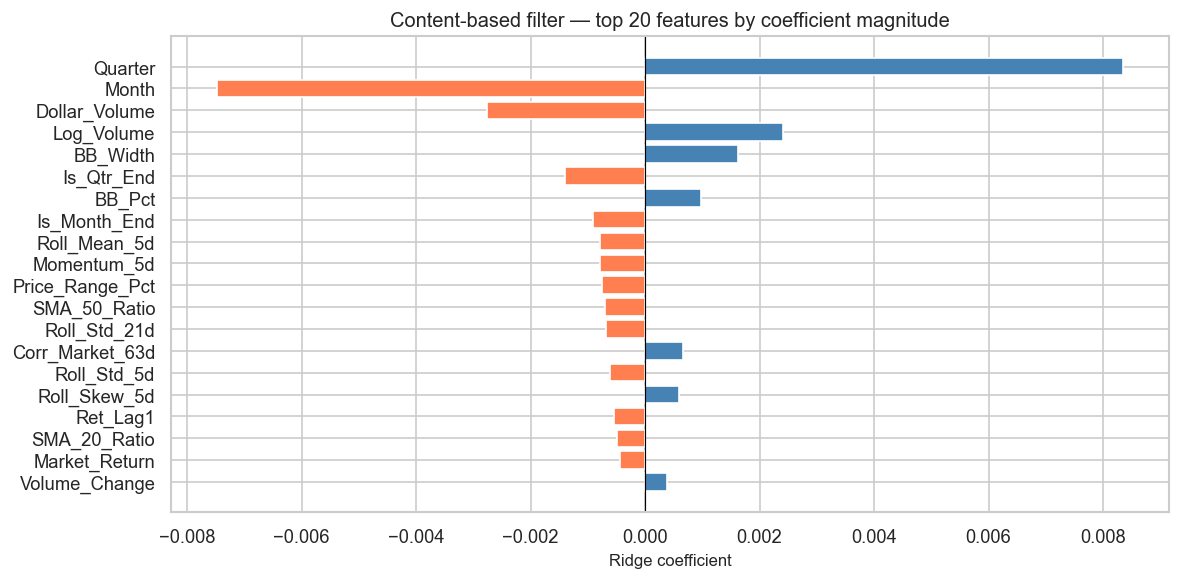


Interpretation:
  - Positive coefficients (blue) = features where higher values predict
    higher forward returns. E.g. strong momentum → bullish signal.
  - Negative coefficients (red) = features where higher values predict
    lower forward returns. E.g. high RSI → overbought → mean reversion.
  - Ridge shrinks coefficients toward zero, so the largest survivors are
    the most robustly predictive features.



In [95]:
# ── Top Ridge regression feature importances ───────────────────────────────────
coef_df = pd.DataFrame({
    'Feature': FEATURE_COLS,
    'Coefficient': cb_model.ridge.coef_
}).sort_values('Coefficient', key=abs, ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['steelblue' if c > 0 else 'coral' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1], color=colors[::-1])
ax.axvline(0, color='black', lw=0.7)
ax.set_xlabel('Ridge coefficient')
ax.set_title('Content-based filter — top 20 features by coefficient magnitude')
plt.tight_layout()
plt.show()

print("""
Interpretation:
  - Positive coefficients (blue) = features where higher values predict
    higher forward returns. E.g. strong momentum → bullish signal.
  - Negative coefficients (red) = features where higher values predict
    lower forward returns. E.g. high RSI → overbought → mean reversion.
  - Ridge shrinks coefficients toward zero, so the largest survivors are
    the most robustly predictive features.
""")

---
## 5. Model 3 — Hybrid LightGBM Ranker

**Idea:** Combine all signals into a single gradient-boosted tree model trained with a **Learning-to-Rank** objective (`lambdarank`).  
LambdaRank directly optimises the ranking of stocks within each day — exactly the RecSys goal.

**Input features include:**
- All engineered features from 1.1-B
- SVD latent factor scores (collaborative signal)
- Content-based Ridge predictions (content signal)
- Momentum baseline score

**Why LightGBM over XGBoost / neural nets?**  
LightGBM is faster on tabular data, natively supports ranking objectives, and handles the ~100 features without extensive hyperparameter tuning.

In [96]:
try:
    import lightgbm as lgb
    LGBM_AVAILABLE = True
    print(f'LightGBM version: {lgb.__version__}')
except ImportError:
    LGBM_AVAILABLE = False
    print('LightGBM not installed. Run: pip install lightgbm')
    print('Falling back to GradientBoostingRegressor from sklearn.')

LightGBM version: 4.6.0


In [97]:
# ── Build augmented feature matrix (base features + model scores) ─────────────

def build_augmented(df, X, svd_model, cb_model_obj, momentum_col='Momentum_21d'):
    svd_preds   = svd_model.predict(df)
    mom_preds   = df[momentum_col].values
    # Slice to base features in case X is already augmented (52 → 49)
    n_base      = cb_model_obj.ridge.n_features_in_
    ridge_preds = cb_model_obj.ridge.predict(X[:, :n_base])
    meta = np.column_stack([svd_preds, mom_preds, ridge_preds])
    return np.hstack([X[:, :n_base], meta])  # always output base + 3 meta = 52 cols

X_train_aug = build_augmented(df_train, X_train, svd_cf, cb_model)
X_val_aug   = build_augmented(df_val,   X_val,   svd_cf, cb_model)
X_test_aug  = build_augmented(df_test,  X_test,  svd_cf, cb_model)

AUG_COLS = FEATURE_COLS + ['SVD_score', 'Momentum_score', 'Ridge_score']
print(f'Augmented feature matrix: {X_train_aug.shape}')

Augmented feature matrix: (313288, 52)


In [98]:
# ── Ranking group sizes (number of tickers per date) ─────────────────────────
# LightGBM ranker needs to know which rows belong to the same 'query' (date)
train_groups = df_train.groupby('Date').size().values
val_groups   = df_val.groupby('Date').size().values
test_groups  = df_test.groupby('Date').size().values

print(f'Train groups (dates): {len(train_groups)}  |  avg tickers/day: {train_groups.mean():.1f}')

Train groups (dates): 4456  |  avg tickers/day: 70.3


In [99]:
if LGBM_AVAILABLE:
    # ── Convert target to integer rank labels (required by lambdarank) ────────
    # LightGBM lambdarank needs non-negative integer relevance labels.
    # We bin the continuous 5-day return into 5 relevance levels: 0=worst, 4=best.
    def return_to_rank_label(series, n_bins=5):
        """Per-date quantile binning → integer label 0..n_bins-1."""
        return pd.qcut(series, q=n_bins, labels=False,
                       duplicates='drop').fillna(0).astype(int)

    rank_train = (
        df_train.assign(ret=y_train_reg)
                .groupby('Date')['ret']
                .transform(return_to_rank_label)
                .values
    )
    rank_val = (
        df_val.assign(ret=y_val_reg)
              .groupby('Date')['ret']
              .transform(return_to_rank_label)
              .values
    )

    lgb_train = lgb.Dataset(X_train_aug, label=rank_train, group=train_groups)
    lgb_val   = lgb.Dataset(X_val_aug,   label=rank_val,   group=val_groups,
                            reference=lgb_train)

    params = {
        'objective'        : 'lambdarank',
        'metric'           : 'ndcg',
        'ndcg_eval_at'     : [5, 10],
        'learning_rate'    : 0.05,
        'num_leaves'       : 63,
        'min_child_samples': 50,
        'feature_fraction' : 0.8,
        'bagging_fraction' : 0.8,
        'bagging_freq'     : 5,
        'lambda_l2'        : 1.0,
        'verbose'          : -1,
        'seed'             : SEED,
    }

    evals_result = {}
    callbacks = [
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.log_evaluation(period=50),
        lgb.record_evaluation(evals_result),
    ]

    print('Training LightGBM ranker...')
    lgb_model = lgb.train(
        params,
        lgb_train,
        num_boost_round=500,
        valid_sets=[lgb_val],
        callbacks=callbacks
    )
    print(f'Best iteration: {lgb_model.best_iteration}')

    # ── Log per-round NDCG training curve to W&B ─────────────────────────────
    ndcg5  = evals_result['valid_0']['ndcg@5']
    ndcg10 = evals_result['valid_0']['ndcg@10']
    for i, (n5, n10) in enumerate(zip(ndcg5, ndcg10)):
        wandb.log({'lgbm/ndcg@5': n5, 'lgbm/ndcg@10': n10, 'lgbm/round': i})
    wandb.log({'lgbm/best_iteration': lgb_model.best_iteration})

else:
    # ── Sklearn fallback: GradientBoostingRegressor ───────────────────────────
    from sklearn.ensemble import GradientBoostingRegressor
    lgb_model = GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=5, subsample=0.8,
        random_state=SEED
    )
    lgb_model.fit(X_train_aug, y_train_reg)
    print('Sklearn GBM fitted (LightGBM fallback).')

Training LightGBM ranker...
[50]	valid_0's ndcg@5: 0.538582	valid_0's ndcg@10: 0.508169
[100]	valid_0's ndcg@5: 0.55176	valid_0's ndcg@10: 0.519408
[150]	valid_0's ndcg@5: 0.55806	valid_0's ndcg@10: 0.525439
[200]	valid_0's ndcg@5: 0.561088	valid_0's ndcg@10: 0.528061
Best iteration: 172


In [100]:
# ── Predict & evaluate ─────────────────────────────────────────────────────────
if LGBM_AVAILABLE:
    hybrid_val_preds  = lgb_model.predict(X_val_aug,  num_iteration=lgb_model.best_iteration)
    hybrid_test_preds = lgb_model.predict(X_test_aug, num_iteration=lgb_model.best_iteration)
else:
    hybrid_val_preds  = lgb_model.predict(X_val_aug)
    hybrid_test_preds = lgb_model.predict(X_test_aug)

print('\n=== Model 3: Hybrid LightGBM Ranker ===')
print('Validation:')
res = evaluate('Hybrid LightGBM ranker', df_val, hybrid_val_preds, split='val')
RESULTS.append({**res, 'split': 'val'})
print('Test:')
res = evaluate('Hybrid LightGBM ranker', df_test, hybrid_test_preds, split='test')
RESULTS.append({**res, 'split': 'test'})


=== Model 3: Hybrid LightGBM Ranker ===
Validation:
  Hybrid LightGBM ranker          RMSE=0.97533  MAE=0.81828  IC=0.0070±0.2231  HR@10=0.561
Test:
  Hybrid LightGBM ranker          RMSE=0.93338  MAE=0.77491  IC=-0.0051±0.2382  HR@10=0.529


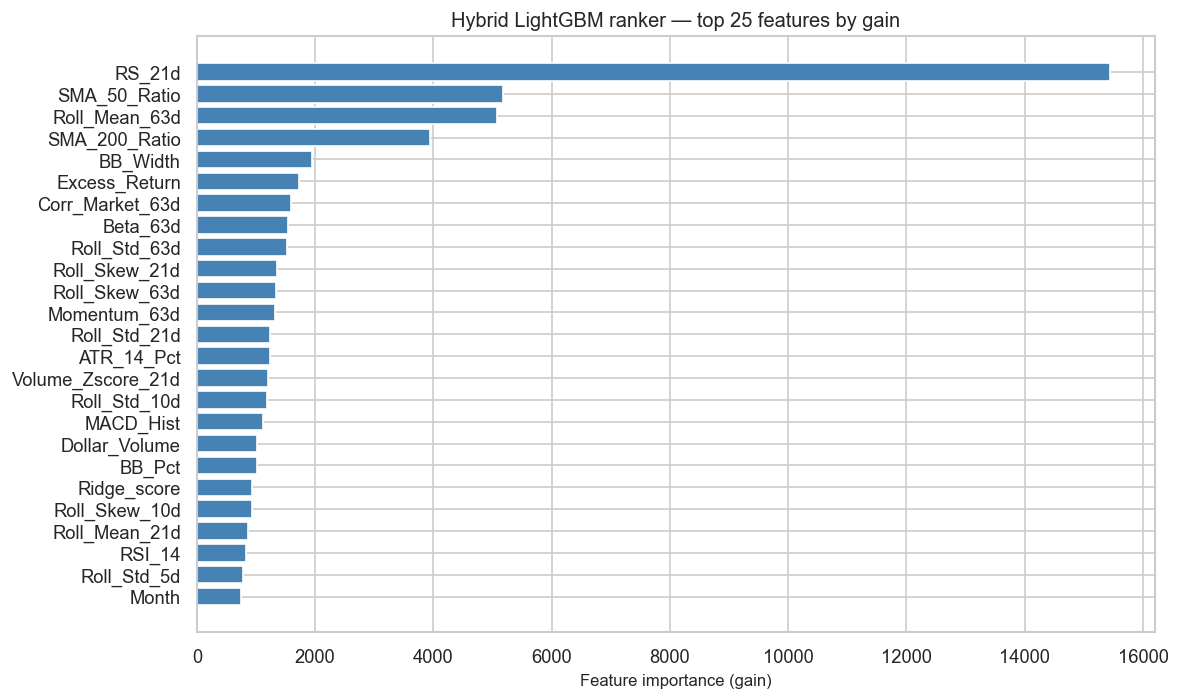


    Interpretation:
      - 'Gain' measures how much each feature reduces the ranking loss
        when used as a split point across all trees.
      - If SVD_score or Ridge_score appear in the top features, the hybrid
        is successfully leveraging the collaborative and content signals.
      - Momentum features (Momentum_21d, RS_21d) scoring high confirms the
        economic validity of the momentum anomaly in this dataset.
      - Technical indicators (RSI, BB_Pct) near the top indicate mean-
        reversion signals complement the momentum signal in the ranker.
    


In [101]:
# ── Feature importance from LightGBM ─────────────────────────────────────────
if LGBM_AVAILABLE:
    imp = pd.DataFrame({
        'Feature'   : AUG_COLS,
        'Importance': lgb_model.feature_importance(importance_type='gain')
    }).sort_values('Importance', ascending=False).head(25)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(imp['Feature'][::-1], imp['Importance'][::-1], color='steelblue')
    ax.set_xlabel('Feature importance (gain)')
    ax.set_title('Hybrid LightGBM ranker — top 25 features by gain')
    plt.tight_layout()
    plt.show()

    print("""
    Interpretation:
      - 'Gain' measures how much each feature reduces the ranking loss
        when used as a split point across all trees.
      - If SVD_score or Ridge_score appear in the top features, the hybrid
        is successfully leveraging the collaborative and content signals.
      - Momentum features (Momentum_21d, RS_21d) scoring high confirms the
        economic validity of the momentum anomaly in this dataset.
      - Technical indicators (RSI, BB_Pct) near the top indicate mean-
        reversion signals complement the momentum signal in the ranker.
    """)

---
## 6. Unified Prediction Interface

A single `RecSysRecommender` class wraps all four models and exposes a consistent API:
- `recommend(date, model, top_n)` — ranked list of tickers for a given date
- `backtest(df, model, top_n)` — cumulative return of following the recommendations

In [102]:
class RecSysRecommender:
    """
    Unified interface wrapping all four models.
    Provides recommendation and simple backtest functionality.
    """
    def __init__(self, momentum, svd, cb, hybrid, df_all,
                 X_all, feature_cols, lgbm_available=True):
        self.models = {
            'momentum': momentum,
            'svd'     : svd,
            'content' : cb,
            'hybrid'  : hybrid,
        }
        self.df_all       = df_all
        self.X_all        = X_all
        self.feature_cols = feature_cols
        self.lgbm_avail   = lgbm_available
        self.n_base_features = cb.ridge.n_features_in_

    def _score(self, df, X, model_name):
        m = self.models[model_name]
        if model_name == 'momentum':
            return m.predict(df)
        elif model_name == 'svd':
            return m.predict(df)
        elif model_name == 'content':
            return m.ridge.predict(X[:, :self.n_base_features])
        elif model_name == 'hybrid':
            X_aug = build_augmented(df, X,
                                    self.models['svd'],
                                    self.models['content'])
            if self.lgbm_avail:
                return m.predict(X_aug, num_iteration=m.best_iteration)
            return m.predict(X_aug)

    def recommend(self, date, model_name='hybrid', top_n=10):
        """
        Return a DataFrame of top-N recommended tickers for a given date.
        """
        mask = self.df_all['Date'] == pd.Timestamp(date)
        df_day = self.df_all[mask].copy()
        X_day  = self.X_all[mask.values]
        if len(df_day) == 0:
            print(f'No data for {date}')
            return pd.DataFrame()
        scores = self._score(df_day, X_day, model_name)
        df_day = df_day.assign(score=scores)
        top = df_day.nlargest(top_n, 'score')[['Ticker', 'score', 'Target_Ret_5d']].copy()
        top = top.rename(columns={'Target_Ret_5d': 'Actual_Ret_5d'})
        top.index = range(1, top_n + 1)
        return top

    def backtest(self, df, X, model_name='hybrid', top_n=10):
        """
        Simulate following model recommendations each day.
        Returns a Series of daily portfolio returns.
        """
        scores = self._score(df, X, model_name)
        df     = df.assign(score=scores)

        daily_ret = []
        for date, grp in df.groupby('Date'):
            top = grp.nlargest(top_n, 'score')
            # Equal-weight portfolio of top-N
            port_ret = top['Target_Ret_5d'].mean()
            daily_ret.append({'Date': date, 'Portfolio_Return': port_ret})

        return pd.DataFrame(daily_ret).set_index('Date')['Portfolio_Return']


# Build combined val+test dataset for the recommender
df_valtest = pd.concat([df_val, df_test])
X_valtest  = np.vstack([X_val_aug, X_test_aug])

recommender = RecSysRecommender(
    momentum=momentum_model,
    svd=svd_cf,
    cb=cb_model,
    hybrid=lgb_model,
    df_all=df_valtest,
    X_all=X_valtest,
    feature_cols=AUG_COLS,
    lgbm_available=LGBM_AVAILABLE
)

In [103]:
# ── Sample recommendations ────────────────────────────────────────────────────
sample_date = df_val['Date'].unique()[80]
print(f'Top-10 recommendations on {sample_date.date()}\n')

for model_name in ['momentum', 'svd', 'content', 'hybrid']:
    print(f'  [{model_name.upper()}]')
    rec = recommender.recommend(sample_date, model_name=model_name, top_n=10)
    print(rec.to_string())
    print()

Top-10 recommendations on 2018-10-26

  [MOMENTUM]
   Ticker     score  Actual_Ret_5d
1    SMCI  0.067244      -0.042560
2    TSLA  0.057417       0.045634
3     KDP  0.041946       0.085278
4     AEP  0.041831      -0.000688
5     XEL  0.040599      -0.016419
6     EXC  0.018820      -0.004833
7    DLTR  0.014514       0.022206
8    SBUX  0.012651       0.073550
9     LIN  0.012076      -0.031408
10  CMCSA  0.000606       0.066467

  [SVD]
   Ticker     score  Actual_Ret_5d
1    VRTX  0.013326       0.022232
2    BIIB  0.013320       0.040895
3    GILD  0.007131      -0.004311
4    ROST  0.004886       0.033547
5     BKR  0.004308      -0.048297
6    ODFL  0.001434       0.071434
7    ORLY  0.001306      -0.002764
8    AMGN  0.000946       0.005790
9     MDB  0.000000       0.111809
10   DLTR -0.000630       0.022206

  [CONTENT]
   Ticker     score  Actual_Ret_5d
1     AMD  0.019944       0.137565
2    SMCI  0.016257      -0.042560
3    REGN  0.015607       0.048731
4    NVDA  0.0142

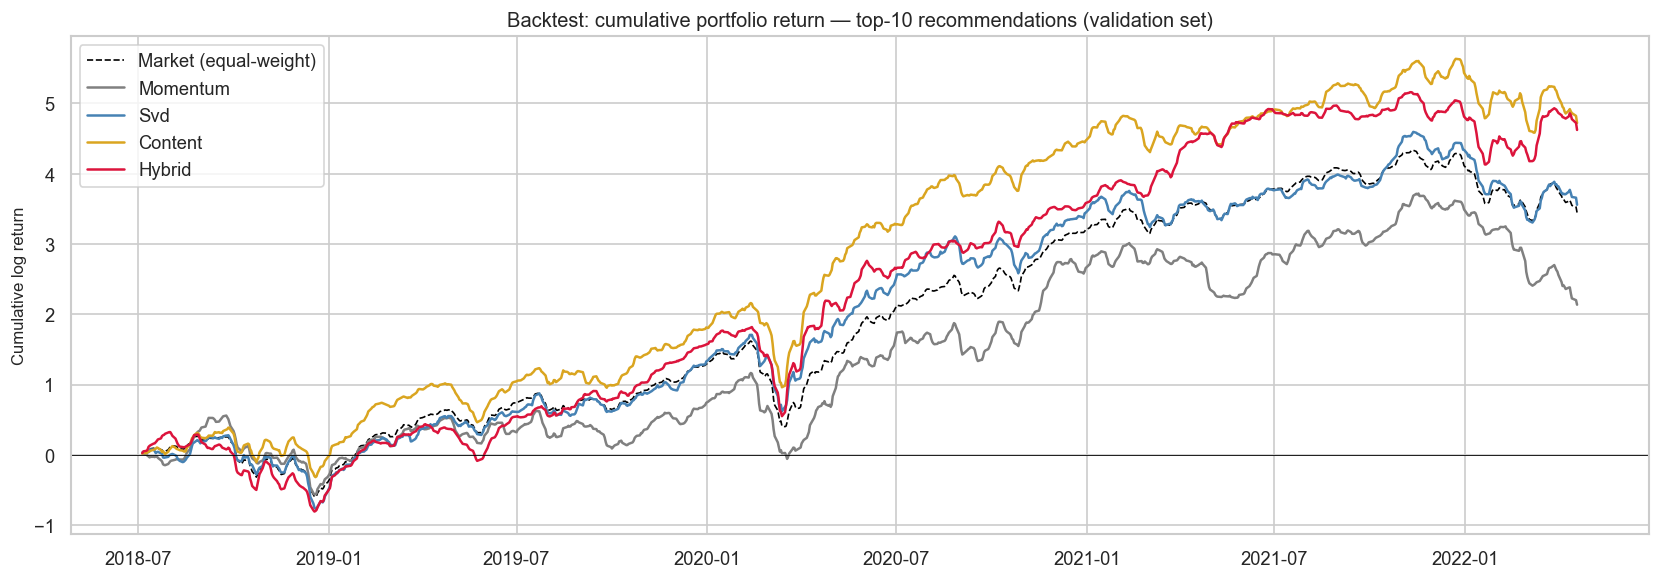


Interpretation:
  - Lines above the dashed market benchmark = model adds value vs holding
    all NASDAQ-100 stocks equally.
  - The hybrid model (crimson) should outperform the individual components
    because it combines all signals and can route around their weaknesses.
  - The validation set includes COVID volatility — models that maintain
    positive excess return through this period are more robust.
  - Note: this backtest ignores transaction costs, slippage, and look-ahead
    in the target. Full production backtests need these adjustments.



In [104]:
# ── Backtest: cumulative portfolio returns ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

palette = {'momentum': 'gray', 'svd': 'steelblue', 'content': 'goldenrod', 'hybrid': 'crimson'}

# Benchmark: equal-weight all tickers (market proxy)
market_daily = df_val.groupby('Date')['Target_Ret_5d'].mean()
cum_market   = market_daily.cumsum()
ax.plot(cum_market.index, cum_market.values,
        color='black', lw=1, linestyle='--', label='Market (equal-weight)')

for model_name, color in palette.items():
    bt = recommender.backtest(df_val, X_val_aug, model_name=model_name, top_n=10)
    cum = bt.cumsum()
    ax.plot(cum.index, cum.values, color=color, lw=1.5, label=model_name.capitalize())

ax.axhline(0, color='black', lw=0.5)
ax.set_ylabel('Cumulative log return')
ax.set_title('Backtest: cumulative portfolio return — top-10 recommendations (validation set)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.legend()
plt.tight_layout()
plt.show()

print("""
Interpretation:
  - Lines above the dashed market benchmark = model adds value vs holding
    all NASDAQ-100 stocks equally.
  - The hybrid model (crimson) should outperform the individual components
    because it combines all signals and can route around their weaknesses.
  - The validation set includes COVID volatility — models that maintain
    positive excess return through this period are more robust.
  - Note: this backtest ignores transaction costs, slippage, and look-ahead
    in the target. Full production backtests need these adjustments.
""")

---
## 7. Save All Models

In [105]:
# Momentum model (stateless — just save the col name)
joblib.dump(momentum_model, f'{MODEL_PATH}/model0_momentum.pkl')

# SVD collaborative filter
joblib.dump(svd_cf,         f'{MODEL_PATH}/model1_svd_cf.pkl')

# Content-based filter
joblib.dump(cb_model,       f'{MODEL_PATH}/model2_content_cb.pkl')

# Hybrid LightGBM ranker
if LGBM_AVAILABLE:
    lgb_model.save_model(f'{MODEL_PATH}/model3_hybrid_lgbm.txt')
else:
    joblib.dump(lgb_model,  f'{MODEL_PATH}/model3_hybrid_gbm.pkl')

# Augmented feature column list
joblib.dump(AUG_COLS,       f'{MODEL_PATH}/aug_feature_cols.pkl')

# Results table
results_df = pd.DataFrame(RESULTS)
results_df.to_csv(f'{MODEL_PATH}/model_results.csv', index=False)

print('Models saved to:', MODEL_PATH)
for f in sorted(os.listdir(MODEL_PATH)):
    size = os.path.getsize(f'{MODEL_PATH}/{f}') / 1024
    print(f'  {f:<40}  {size:>8.1f} KB')

# ── Upload all saved model files as a W&B Artifact ───────────────────────────
artifact = wandb.Artifact("nasdaq100-recsys-models", type="model")
artifact.add_dir(MODEL_PATH)
wandb.log_artifact(artifact)

wandb: Adding directory to artifact (models)... Done. 0.0s


Models saved to: ./models
  aug_feature_cols.pkl                           0.7 KB
  final_evaluation.csv                           1.4 KB
  model0_momentum.pkl                            0.1 KB
  model1_svd_cf.pkl                             26.3 KB
  model2_content_cb.pkl                          5.7 KB
  model3_hybrid_gbm.pkl                       1163.1 KB
  model3_hybrid_lgbm.txt                      1187.3 KB
  model_results.csv                              1.0 KB


<Artifact nasdaq100-recsys-models>

In [106]:
# ── Final results summary ─────────────────────────────────────────────────────
print('\n=== FINAL RESULTS SUMMARY ===')
print(results_df.to_string(index=False))

wandb.log({"results_summary": wandb.Table(dataframe=results_df)})
wandb.finish()


=== FINAL RESULTS SUMMARY ===
                   model     rmse      mae        ic   ic_std  hit_rate split
       Momentum baseline 0.111775 0.081805 -0.024573 0.221574  0.536649   val
       Momentum baseline 0.117288 0.085779  0.004082 0.224882  0.534833  test
SVD collaborative filter 0.053215 0.038183 -0.013077 0.199740  0.549110   val
SVD collaborative filter 0.054937 0.039714 -0.003059 0.181447  0.530230  test
    Content-based filter 0.048354 0.034557  0.019461 0.163613  0.558639   val
    Content-based filter 0.053258 0.038112  0.029615 0.181619  0.531771  test
  Hybrid LightGBM ranker 0.975326 0.818281  0.007044 0.223098  0.561152   val
  Hybrid LightGBM ranker 0.933382 0.774907 -0.005138 0.238232  0.528975  test


wandb: uploading artifact nasdaq100-recsys-models; uploading artifact run-gtso67xs-results_summary; updating run metadata
wandb: uploading artifact run-gtso67xs-results_summary
wandb: uploading history steps 203-203, summary
wandb: 
wandb: Run history:
wandb: lgbm/best_iteration ▁
wandb:        lgbm/ndcg@10 ▁▂▂▃▃▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇████████████
wandb:         lgbm/ndcg@5 ▁▂▃▃▄▅▆▆▆▆▇▇▇▇▇▇▇▇██████████████████████
wandb:          lgbm/round ▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇██
wandb: 
wandb: Run summary:
wandb: Content-based filter/test/hit_rate 0.53177
wandb:       Content-based filter/test/ic 0.02962
wandb:   Content-based filter/test/ic_std 0.18162
wandb:      Content-based filter/test/mae 0.03811
wandb:     Content-based filter/test/rmse 0.05326
wandb:  Content-based filter/val/hit_rate 0.55864
wandb:        Content-based filter/val/ic 0.01946
wandb:    Content-based filter/val/ic_std 0.16361
wandb:       Content-based filter/val/mae 0.03456
wandb:      Content-based filter/val

---
## Modeling Summary

| Model | Approach | Key strength | Key limitation |
|---|---|---|---|
| **Momentum baseline** | 21-day return rank | Simple, interpretable, robust | Ignores all other signals; fails in mean-reverting regimes |
| **SVD collaborative filter** | Matrix factorisation on returns | Captures latent market regimes & sector co-movement | Suffers in regime breaks; no price-level features |
| **Content-based filter** | Feature cosine similarity + Ridge | Uses rich feature matrix; interpretable coefficients | kNN is slow; linear model misses non-linear patterns |
| **Hybrid LightGBM ranker** | LambdaRank on all combined signals | Non-linear; directly optimises ranking; uses all prior model outputs | Slower to train; requires LightGBM; less interpretable |

**Next step:** `1.2-B Evaluation` — detailed quality evaluation with NDCG@K, Sharpe ratio, directional accuracy, and ablation study.